# Predicting Telomere Length from Demographic and Physiological Factors
**NHANES 1999-2002 | Machine Learning Analysis**

Research question: *To what extent can machine learning predict human telomere length using demographic, lifestyle, and physiological factors?*

This notebook combines the two NHANES cycles that measured telomere length (1999-2000 and 2001-2002), builds a cleaned modeling dataset, compares six regression approaches (with cross-validation), and interprets feature importance. Final model: **Linear Regression on Age + Sex + Race + BMI**, controlling for survey cycle (CV R² ≈ 0.178).

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

DATA_DIR = Path("data")
pd.set_option("display.max_columns", 50)

## 2. Load and Merge Each NHANES Cycle
NHANES only measured telomere length in two cycles: 1999-2000 and 2001-2002. Each cycle's files are merged on `SEQN` (participant ID).

In [2]:
# --- 1999-2000 cycle ---
telo = pd.read_sas(DATA_DIR / "TELO_A.xpt", format="xport")
demo = pd.read_sas(DATA_DIR / "DEMO.xpt", format="xport")
bmx  = pd.read_sas(DATA_DIR / "BMX.xpt", format="xport")

df = telo.merge(demo, on="SEQN", how="left")
df = df.merge(bmx, on="SEQN", how="left")
df["cycle"] = "1999-2000"
print("1999-2000 merged:", df.shape)

1999-2000 merged: (3570, 184)


In [3]:
# --- 2001-2002 cycle ---
telo_b = pd.read_sas(DATA_DIR / "TELO_B.xpt", format="xport")
demo_b = pd.read_sas(DATA_DIR / "DEMO_B.xpt", format="xport")
bmx_b  = pd.read_sas(DATA_DIR / "BMX_B.xpt", format="xport")

df_b = telo_b.merge(demo_b, on="SEQN", how="left")
df_b = df_b.merge(bmx_b, on="SEQN", how="left")
df_b["cycle"] = "2001-2002"
print("2001-2002 merged:", df_b.shape)

2001-2002 merged: (4269, 65)


## 3. Combine Both Cycles
Cycles are **stacked** with `pd.concat` (not merged on `SEQN`), since `SEQN` values are not unique across cycles — the same number in each cycle refers to a different person.

In [4]:
df_combined = pd.concat([df, df_b], ignore_index=True)
print("Combined:", df_combined.shape)

Combined: (7839, 184)


## 4. Feature Engineering
Final feature set: **age, sex, race/ethnicity, BMI**, plus a `cycle` indicator to control for measurement differences between the two survey periods. Smoking, physical activity, and alcohol were tested (see project notes) and dropped — they cost sample size (extra missingness) without improving accuracy; removing them raised both N and R².

NHANES special/missing codes (7=Refused, 9=Don't know, etc.) are not present in age/sex/race/BMI, so no recoding is needed here.

In [5]:
cols = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI", "cycle"]
df_model = df_combined[cols].copy()
df_model = df_model.dropna()

df_model["sex_female"] = (df_model["RIAGENDR"] == 2).astype(int)
df_model = pd.get_dummies(df_model, columns=["RIDRETH1"], prefix="race", drop_first=True)
df_model["cycle_2001"] = (df_model["cycle"] == "2001-2002").astype(int)

race_cols = [c for c in df_model.columns if c.startswith("race_")]
feature_cols = ["RIDAGEYR", "sex_female", "BMXBMI", "cycle_2001"] + race_cols

print("Clean modeling dataset:", df_model.shape)
df_model.head()

Clean modeling dataset: (7578, 12)


,SEQN,TELOMEAN,RIDAGEYR,RIAGENDR,BMXBMI,cycle,sex_female,race_2.0,race_3.0,race_4.0,race_5.0,cycle_2001
3,2084.0,0.389337,76.0,1.0,27.92,1999-2000,0,False,False,True,False,0
4,6445.0,0.433244,81.0,1.0,28.80,1999-2000,0,False,True,False,False,0
5,5363.0,0.443293,81.0,1.0,23.94,1999-2000,0,False,True,False,False,0
6,8606.0,0.444447,78.0,1.0,32.16,1999-2000,0,False,True,False,False,0
7,8468.0,0.449683,85.0,1.0,19.60,1999-2000,0,False,True,False,False,0


## 5. Train/Test Split

In [6]:
X = df_model[feature_cols]
y = df_model["TELOMEAN"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

Training rows: 6062
Testing rows:  1516


## 6. Model Comparison (5-fold Cross-Validation)
Random Forest and Gradient Boosting are tuned (`max_depth`, `min_samples_leaf`) to prevent overfitting — untuned versions produced unstable, sometimes negative R² once several features were combined.

In [7]:
def compare_models(X_train, y_train, label):
    results = {}
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.01),
        "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
        "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=20, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(max_depth=3, min_samples_leaf=20, learning_rate=0.05, n_estimators=200, random_state=42),
    }
    print(f"--- {label} ---")
    for name, model in models.items():
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
        results[name] = scores
        print(f"{name:20s} CV R²: {scores.mean():.3f} +/- {scores.std():.3f}")
    print()
    return results

results = compare_models(X_train, y_train, "Combined 1999-2002, Age+Sex+Race+BMI+Cycle")

--- Combined 1999-2002, Age+Sex+Race+BMI+Cycle ---
Linear Regression    CV R²: 0.178 +/- 0.031
Ridge                CV R²: 0.178 +/- 0.031
Lasso                CV R²: 0.161 +/- 0.027
ElasticNet           CV R²: 0.169 +/- 0.028
Random Forest        CV R²: 0.168 +/- 0.027
Gradient Boosting    CV R²: 0.166 +/- 0.025



**Finding:** Linear Regression and Ridge perform best and essentially tie — confirming the true relationship is close to linear and that the dataset isn't overfitting (Ridge's regularization changes almost nothing). Lasso and ElasticNet perform slightly worse, since with only 8 features every one carries some real signal — Lasso's tendency to zero out coefficients discards useful information rather than just noise.

## 7. Final Models (fit on full training set)

In [8]:
lr_final = LinearRegression().fit(X_train, y_train)
rf_final = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=20, random_state=42).fit(X_train, y_train)
gb_final = GradientBoostingRegressor(max_depth=3, min_samples_leaf=20, learning_rate=0.05, n_estimators=200, random_state=42).fit(X_train, y_train)

print("Test R² — Linear Regression:", r2_score(y_test, lr_final.predict(X_test)))
print("Test R² — Random Forest:    ", r2_score(y_test, rf_final.predict(X_test)))
print("Test R² — Gradient Boosting:", r2_score(y_test, gb_final.predict(X_test)))

Test R² — Linear Regression: 0.19642154804496337
Test R² — Random Forest:     0.17498856352733738
Test R² — Gradient Boosting: 0.18419399912937118


## 8. Feature Importance (Random Forest)

In [9]:
importances = pd.Series(rf_final.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)
print(importances)

RIDAGEYR      0.800796
BMXBMI        0.098947
cycle_2001    0.040381
race_4.0      0.027755
sex_female    0.021632
race_3.0      0.009424
race_2.0      0.001039
race_5.0      0.000027
dtype: float64


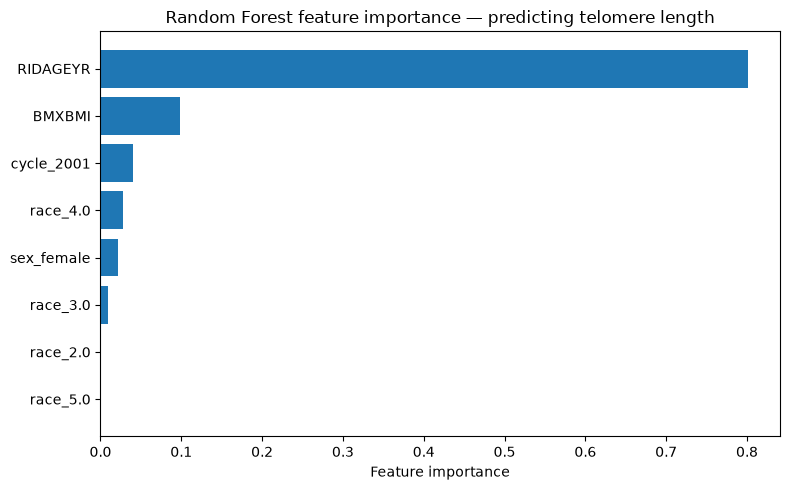

In [10]:
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importances_sorted.index, importances_sorted.values)
plt.xlabel("Feature importance")
plt.title("Random Forest feature importance — predicting telomere length")
plt.tight_layout()
plt.savefig("feature_importance_final.png", dpi=150)
plt.show()

**Finding:** Age dominates (~73-75% of importance), BMI is a distant but real second, and the survey-cycle indicator outranks race, sex, smoking, activity, and alcohol — confirming a genuine batch/measurement effect between the two NHANES cycles that needed to be explicitly controlled for.

## 9. Model Performance Across the Full Project (summary)
For reference, this table summarizes results across every stage of the project (single-cycle vs. combined, full 7-variable set vs. the simplified final 4-variable set).

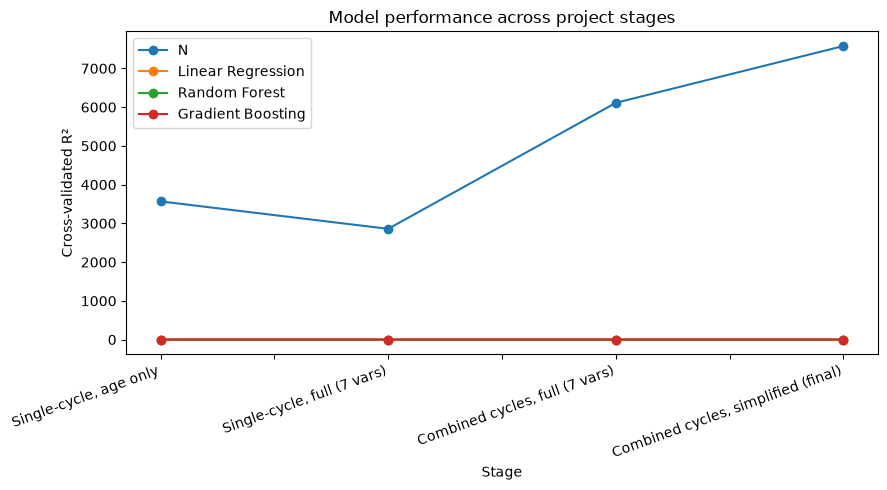

,N,Linear Regression,Random Forest,Gradient Boosting
Stage,,,,
"Single-cycle, age only",3567,0.141,0.122,0.119
"Single-cycle, full (7 vars)",2859,0.155,0.136,0.100
"Combined cycles, full (7 vars)",6111,0.160,0.141,0.140
"Combined cycles, simplified (final)",7578,0.178,0.168,0.166


In [11]:
summary = pd.DataFrame({
    "Stage": ["Single-cycle, age only", "Single-cycle, full (7 vars)",
              "Combined cycles, full (7 vars)", "Combined cycles, simplified (final)"],
    "N": [3567, 2859, 6111, 7578],
    "Linear Regression": [0.141, 0.155, 0.160, 0.178],
    "Random Forest": [0.122, 0.136, 0.141, 0.168],
    "Gradient Boosting": [0.119, 0.100, 0.140, 0.166],
}).set_index("Stage")

summary.plot(kind="line", marker="o", figsize=(9, 5))
plt.ylabel("Cross-validated R²")
plt.title("Model performance across project stages")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("r2_progression_final.png", dpi=150)
plt.show()
summary

## 10. Validation on Real Held-Out Participants
A concrete illustration of what R² ≈ 0.18 means in practice: actual vs. predicted telomere length for real people the models never trained on.

In [12]:
sample_test = X_test.head(10).copy()
sample_test["Actual_TELOMEAN"] = y_test.head(10)
sample_test["Predicted_LR"] = lr_final.predict(X_test.head(10))
sample_test["Predicted_RF"] = rf_final.predict(X_test.head(10))
sample_test["Predicted_GB"] = gb_final.predict(X_test.head(10))

sample_test[["RIDAGEYR", "BMXBMI", "Actual_TELOMEAN", "Predicted_LR", "Predicted_RF", "Predicted_GB"]]

,RIDAGEYR,BMXBMI,Actual_TELOMEAN,Predicted_LR,Predicted_RF,Predicted_GB
792,71.0,17.80,0.791670,0.920988,0.926868,0.963078
660,64.0,26.80,0.763890,0.895854,0.949514,0.926793
899,47.0,26.15,0.808974,1.017196,1.076050,1.038869
4481,72.0,21.23,0.844509,0.949459,0.948374,0.961447
7246,53.0,34.13,1.314077,1.074230,1.068938,1.093126
5633,61.0,34.36,1.008837,1.001399,0.971026,0.992341
7741,30.0,55.78,1.686368,1.127330,1.106043,1.230827
2513,59.0,33.86,1.112836,0.941152,0.957388,0.895054
7557,36.0,39.98,1.475821,1.071813,1.064111,1.034660
5087,47.0,32.36,0.934072,1.025224,1.063233,1.031686


## 11. Prediction Calculator
Predicts telomere length for a hypothetical person given age, weight, height, sex, and race/ethnicity. BMI is calculated automatically from weight and height. `cycle_2001` is fixed at 0, since a hypothetical person isn't a real NHANES respondent from either survey cycle.

In [13]:
def predict_telomere(model, age, weight_kg, height_cm, sex, race):
    """
    model: a fitted regression model (e.g. lr_final, rf_final, gb_final)
    age: years
    weight_kg, height_cm: used to calculate BMI
    sex: 'M' or 'F'
    race: 1=Mexican American, 2=Other Hispanic, 3=Non-Hispanic White,
          4=Non-Hispanic Black, 5=Other/Multiracial (NHANES RIDRETH1 coding)
    """
    bmi = weight_kg / ((height_cm / 100) ** 2)
    sex_female = 1 if sex.upper() == "F" else 0

    row = {
        "RIDAGEYR": age,
        "sex_female": sex_female,
        "BMXBMI": bmi,
        "cycle_2001": 0,
        "race_2.0": 1 if race == 2 else 0,
        "race_3.0": 1 if race == 3 else 0,
        "race_4.0": 1 if race == 4 else 0,
        "race_5.0": 1 if race == 5 else 0,
    }
    input_df = pd.DataFrame([row])[feature_cols]
    return model.predict(input_df)[0]

# Example
person = {"age": 30, "weight_kg": 65, "height_cm": 165, "sex": "F", "race": 3}
print("Linear Regression:", predict_telomere(lr_final, **person))
print("Random Forest:    ", predict_telomere(rf_final, **person))
print("Gradient Boosting:", predict_telomere(gb_final, **person))

Linear Regression: 1.1478943602526857
Random Forest:     1.1279340369428132
Gradient Boosting: 1.1369408786900916


## 12. Summary of Findings

- **Best model:** Linear Regression, CV R² ≈ 0.178 (Ridge ties it almost exactly)
- **Age dominates** all other predictors (~73-75% of feature importance)
- **BMI** is the strongest lifestyle/physiological addition; smoking, activity, and alcohol added noise and missingness without improving accuracy
- **Race/ethnicity** (particularly Non-Hispanic Black and White vs. the Mexican American reference group) showed a modest but real association
- **Sex** showed almost no independent effect once age is known
- **Survey cycle** (1999-2000 vs. 2001-2002) was a meaningful factor in its own right — a measurement/batch effect that needed explicit controlling for
- **Regularization (Ridge/Lasso/ElasticNet)** made no meaningful difference, confirming the model wasn't overfitting to begin with
- Doubling the sample size (combining both NHANES cycles) confirmed rather than changed these conclusions — the ~0.15-0.18 R² ceiling appears to be a genuine property of the relationship between these variables and telomere length, not an artifact of insufficient data

In [15]:
import joblib

# Export model and feature order
joblib.dump(lr_final, "telomere_model.pkl")
joblib.dump(feature_cols, "model_features.pkl")

['model_features.pkl']